In [1]:
from utils.file_utils import FileUtils
from utils.analysis_util import AnalysisUtil
from utils.config_utils import DataConfig
import pandas as pd
from utils.data_utils import DataUtils
from utils.plot_utils import PlotUtils

In [2]:
data = FileUtils.read_csv_file(DataConfig.FilePath)
data

,Time(ms),Frame begin,behaviorcamframes,optostim,pmtshutterclosing,tone,puff
0,6.670002e-02,5.085144,2.306824,-0.046082,0.003967,0.536194,0.000305
1,3.428381e+01,5.082703,0.271301,-0.043640,0.005188,0.524597,0.000000
2,6.836752e+01,5.083008,1.033020,-0.046082,0.004578,0.531006,-0.002747
3,1.025846e+02,5.083923,0.270691,-0.046692,0.002289,0.533142,-0.000916
4,1.366683e+02,5.082703,1.036682,-0.046692,0.003357,0.532227,0.000916
...,...,...,...,...,...,...,...
64017,2.183926e+06,5.086975,0.267639,-0.044861,0.003204,0.524597,0.000610
64018,2.183960e+06,5.083313,0.267944,-0.043640,0.003204,0.523682,-0.000610
64019,2.183994e+06,5.081177,0.265808,-0.042419,0.003967,0.526123,0.002136
64020,2.184028e+06,5.086975,0.268250,-0.043640,0.002747,0.523987,-0.000305


In [3]:
suite2p_data = FileUtils.read_mat_file(DataConfig.Suite2pPath)

In [4]:
print(suite2p_data.keys())
F = suite2p_data['F']
iscell = suite2p_data['iscell']

dict_keys(['__header__', '__version__', '__globals__', 'stat', 'ops', 'F', 'Fneu', 'spks', 'iscell', 'redcell'])


In [11]:
iscell_df = pd.DataFrame(iscell)

filtered_iscell = DataUtils.filter_rows_by_threshold(
    iscell_df,
    column=1,
    threshold=0.7,
    operator=">"
)

filtered_iscell = DataUtils.filter_rows_by_threshold(
    filtered_iscell,
    column=0,
    threshold=1,
    operator="=="
)

F_subset = F[filtered_iscell.index]
F_subset

array([[ 59.149937, 218.01114 , 412.9315  , ..., 199.36597 , 331.58807 ,
        392.00455 ],
       [ 40.733803, 306.323   ,  73.488655, ..., 267.3479  , 161.02979 ,
         87.93715 ],
       [ 77.37945 , 118.85689 ,  76.18735 , ...,  24.538456, 216.31583 ,
         70.1959  ],
       ...,
       [  9.809528,  10.077004,  35.773903, ...,  15.529022,  44.962856,
         34.016533],
       [126.56187 , 251.27203 , 141.80942 , ...,  79.44999 ,  88.255325,
        177.73328 ],
       [ 12.307676,  13.781424, 107.559364, ...,  40.40319 , 112.46123 ,
         70.36949 ]], shape=(123, 64000), dtype=float32)

In [17]:
dff, f0 = AnalysisUtil.calculate_dff(F_subset, 30, window_seconds=30, percentile=10)

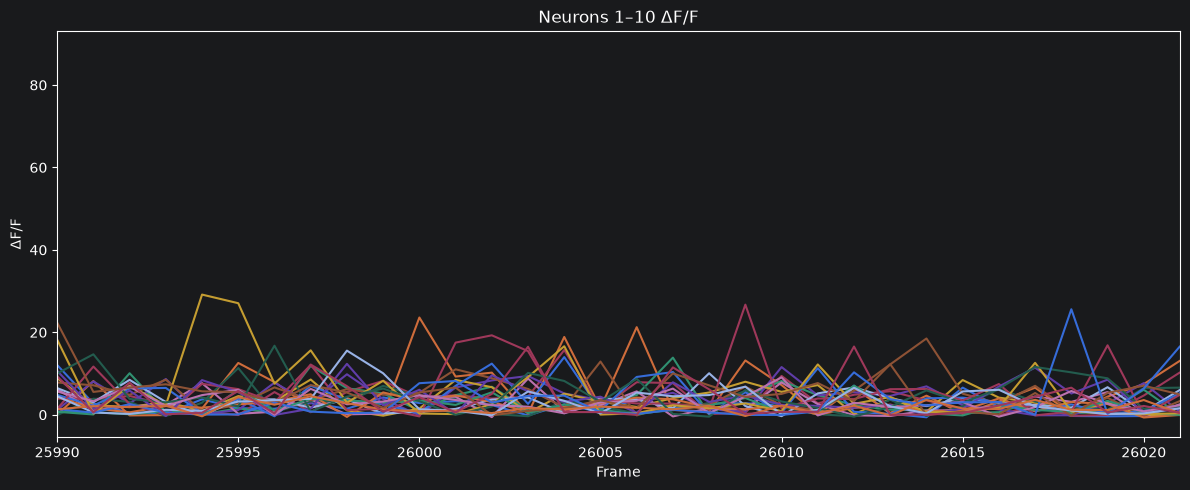

In [24]:
PlotUtils.draw_line_plot(
    dff[100:130],
    x_label="Frame",
    y_label="dF/F",
    title="Neurons 1–10 dF/F",
    x_start=25990,
    x_stop=26021
)